In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import sys
import json
from shapely.geometry import shape
from hotelling.spatial.admin import join_lor_names

# Find repo root
REPO_ROOT = Path.cwd().parent
print(f"Repo root: {REPO_ROOT}")

REPORT_ROOT = REPO_ROOT / "report"

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from hotelling.spatial.boundaries import load_boundary

PATH_RAW = REPO_ROOT / Path('data/raw')
PATH_PROCESSED = REPO_ROOT / Path('data/processed')

# Midpoint table (center coordinates)
zensus = gpd.read_parquet(PATH_RAW / 'zensus2022_grid.parquet')
zensus_filtered = gpd.read_parquet(PATH_RAW / 'zensus2022_grid_filtered.parquet')
lor = gpd.read_parquet(PATH_PROCESSED / 'lor.parquet')

# CRITICAL FIX: berlin.geojson has EPSG:3035 coordinates but geopandas auto-detects as EPSG:4326
# We must force the correct CRS instead of transforming from the wrong one
with open(PATH_RAW / 'city_boundary_Berlin.geojson', 'r') as f:
    berlin_json = json.load(f)
berlin = gpd.GeoDataFrame([1], geometry=[shape(berlin_json['geometry'])], crs='EPSG:3035')

boundary = load_boundary(PATH_RAW / 'relation_boundary_14983.geojson')

# Load pop_grid

grid = gpd.read_parquet(PATH_PROCESSED / 'pop_grid.parquet')

# Build squares from points of grid
grid['geometry'] = grid.apply(lambda row: row.geometry.buffer(50, cap_style='square'), axis=1)
grid['index'] = grid.index

Repo root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/DEDA Project/DEDA_LLM_Spatial_Hotelling


In [2]:
# Load the OSM supermarkets data
osm_supermarkets = gpd.read_parquet(PATH_PROCESSED / 'supermarkets.parquet')

In [3]:
# Load gtfs data for public transport stops
stops = pd.read_csv(PATH_RAW / 'gtfs' / 'stops.txt')
stops = gpd.GeoDataFrame(
    stops,
    geometry=gpd.points_from_xy(stops.stop_lon, stops.stop_lat),
    crs='EPSG:4326'
).to_crs('EPSG:3035')

# Include only stops in within Berlin
# stops = stops[stops.intersects(berlin.geometry[0])]


In [4]:
# Load the rest of the data
routes     = pd.read_csv(PATH_RAW / 'gtfs' / "routes.txt")
trips      = pd.read_csv(PATH_RAW / 'gtfs' / "trips.txt")
stop_times = pd.read_csv(PATH_RAW / 'gtfs' / "stop_times.txt")

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_46951/3273831377.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  trips      = pd.read_csv(PATH_RAW / 'gtfs' / "trips.txt")
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_46951/3273831377.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(PATH_RAW / 'gtfs' / "stop_times.txt")


In [5]:
# One representative trip per route+direction (pick first)
rep_trips = (
    trips.groupby(["route_id", "direction_id"], as_index=False)
         .first()[["route_id", "direction_id", "trip_id"]]
)

# Join: route → trip → stop_times → stop coords
seq = (
    rep_trips
    .merge(stop_times[["trip_id", "stop_id", "stop_sequence"]], on="trip_id")
    .merge(stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]], on="stop_id")
    .merge(routes[["route_id", "route_short_name", "route_type"]], on="route_id")
    .sort_values(["route_id", "direction_id", "stop_sequence"])
)

In [6]:
seq.to_csv(PATH_PROCESSED / 'representative_routes.csv', index=False)

In [7]:
seq

,route_id,direction_id,trip_id,stop_id,stop_sequence,stop_name,stop_lat,stop_lon,route_short_name,route_type
0,10141_109,0,247802165,de:11000:900053301:2:52,0,S Wannsee Bhf (Berlin),52.421546,13.180177,S1,109
1,10141_109,0,247802165,de:11000:900052201:1:51,1,S Nikolassee (Berlin),52.431741,13.194195,S1,109
2,10141_109,0,247802165,de:11000:900050355:1:51,2,S Schlachtensee (Berlin),52.440069,13.215529,S1,109
3,10141_109,0,247802165,de:11000:900050301:1:51,3,S Mexikoplatz (Berlin),52.436719,13.233192,S1,109
4,10141_109,0,247802165,de:11000:900049201:1:51,4,S Zehlendorf (Berlin),52.430876,13.258140,S1,109
...,...,...,...,...,...,...,...,...,...,...
40878,9813_700,1,236990187,de:12062:900415929::2,26,"Massen, Am Industriepark",51.637194,13.739781,599,700
40879,9813_700,1,236990187,de:12062:900415928::1,27,"Massen, Feuerwehr",51.643178,13.731242,599,700
40880,9813_700,1,236990187,de:12062:900415142::2,28,"Massen, Schule",51.640436,13.730069,599,700
40881,9813_700,1,236990187,de:12062:900415004::2,29,"Finsterwalde, Cottbuser Str.",51.635499,13.722040,599,700


/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_46951/2410233323.py:9: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


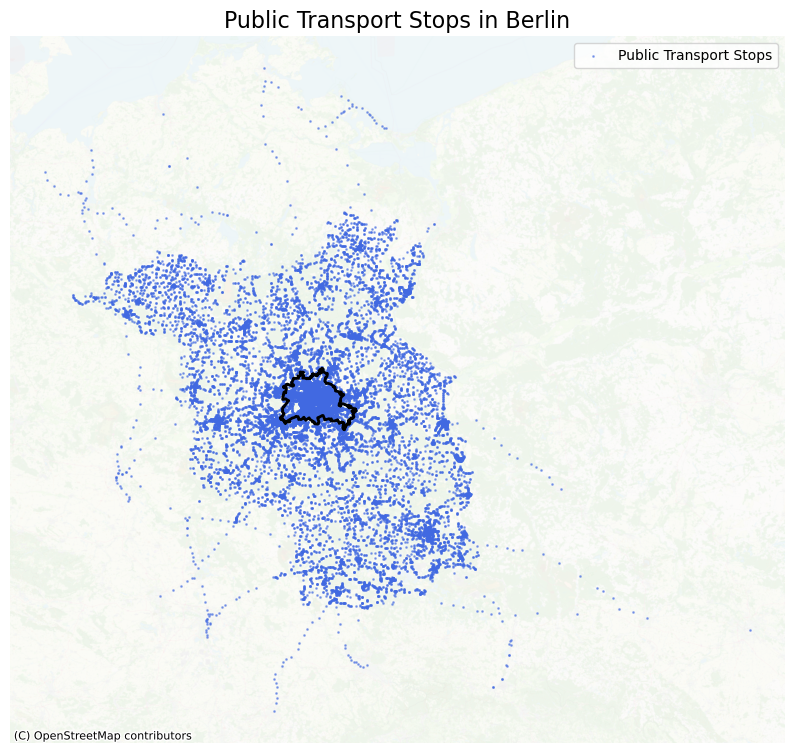

In [ ]:
'''
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
stops[stops['parent_station'].isna()].plot(ax=ax, color='royalblue', markersize=1, label='Public Transport Stops', alpha=0.5)
berlin.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, label='Berlin Boundary')
ctx.add_basemap(ax, crs=berlin.crs, source=ctx.providers.OpenStreetMap.Mapnik, zoom=11, zorder=0, alpha = 0.2)
ax.set_axis_off()
ax.legend()
plt.title('Public Transport Stops in Berlin', fontsize=16)
plt.show()
'''

In [9]:
def gitter_id(row):
    if row['GITTER_ID_100m'] is not None:
        return row['GITTER_ID_100m']
    else: 
        return str(f"CRS3035RES100mN{row['y_mp_100m']}E{row['x_mp_100m']}")
    
grid['cell_id'] = grid.apply(gitter_id, axis=1)

In [10]:
import partridge as ptg  # pip install partridge

# Bounding box: inner Ring + buffer, in WGS84
BBOX = tuple(berlin.to_crs("EPSG:4326").total_bounds)  # (min_lon, min_lat, max_lon, max_lat)

view = {
    "stops.txt": {
        "stop_lat": lambda x: (x >= BBOX[1]) & (x <= BBOX[3]),
        "stop_lon": lambda x: (x >= BBOX[0]) & (x <= BBOX[2]),
    }
}
feed = ptg.load_feed(str(PATH_RAW / "gtfs"), view=view)
# Then write trimmed feed back out
ptg.writers.write_feed_dangerously(feed, str(PATH_RAW / "gtfs_berlin"))

'/Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/DEDA Project/DEDA_LLM_Spatial_Hotelling/data/raw/gtfs_berlin.zip'

In [ ]:
import os
import shutil

# Must be set before r5py import — JPype starts the JVM on import and
# won't accept arguments afterwards; r5py.config does not exist at module level
os.environ["JAVA_TOOL_OPTIONS"] = "-Xmx10G -XX:+UseG1GC"

gtfs_zip = PATH_RAW / "gtfs_berlin.zip"
if not gtfs_zip.exists():
    shutil.make_archive(str(PATH_RAW / "gtfs_berlin"), "zip", root_dir=PATH_RAW, base_dir="gtfs_berlin")

import r5py

# 1. Build transport network (done once, ~2–3 min)
transport_network = r5py.TransportNetwork(
    osm_pbf=PATH_RAW / "berlin-260512.osm.pbf",
    gtfs=[PATH_RAW / "gtfs_berlin.zip"],
)

In [ ]:
from datetime import datetime, timedelta

DEPARTURE = datetime(2025, 10, 7, 10, 0)  # Tuesday, within feed validity
WALKING_SPEED_KMH = 4.8                   # r5py default, ≈ 1.33 m/s

# 2. Origins: grid cell centroids (r5py requires an "id" column, EPSG:4326)
origins = grid[["cell_id", "geometry"]].copy().rename(columns={"cell_id": "id"})
origins.geometry = origins.geometry.centroid.to_crs("EPSG:4326")

# 3. Destinations: supermarket points (r5py requires an "id" column)
osm_supermarkets["store_id"] = osm_supermarkets.index
destinations = (
    osm_supermarkets[["store_id", "geometry"]]
    .to_crs("EPSG:4326")
    .rename(columns={"store_id": "id"})
)

# 4. Compute matrix — TravelTimeMatrix IS a DataFrame, no .compute_travel_times() needed
travel_times = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins,
    destinations=destinations,
    departure=DEPARTURE,
    departure_time_window=timedelta(hours=2),
    transport_modes=[r5py.TransportMode.TRANSIT, r5py.TransportMode.WALK],
    max_time=timedelta(minutes=60),
    max_time_walking=timedelta(minutes=10),   # ≈ 750 m at 4.8 km/h
    speed_walking=WALKING_SPEED_KMH,
    percentiles=[50],
)
# Columns: from_id, to_id, travel_time_p50 (minutes)